In [ ]:
import os
import sys
import json
import time
import uuid
import hmac
import yaml
import hashlib
import random
import shutil
import subprocess
from dataclasses import dataclass, asdict
from datetime import datetime, timezone
from typing import Any, Dict, List, Callable, Optional

def pip_install(*packages):
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", *packages],
        check=False
    )

pip_install("pyyaml", "pandas", "networkx", "matplotlib", "rich")
pip_install("agent-governance-toolkit[full]")

from rich.console import Console
from rich.table import Table
from rich.panel import Panel
from rich import box
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

console = Console()

REPO_URL = "https://github.com/microsoft/agent-governance-toolkit"
REPO_DIR = "/content/agent-governance-toolkit"

if not os.path.exists(REPO_DIR):
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=False)

official_govern = None
official_import_error = None

try:
    from agentmesh.governance import govern as official_govern
except Exception as e:
    official_import_error = repr(e)

In [ ]:
POLICY_PATH = "/content/advanced_agent_policy.yaml"

policy_yaml = """
apiVersion: governance.toolkit/v1
name: advanced-colab-governance-policy
default_action: allow

metadata:
  owner: ai-platform-team
  environment: tutorial
  description: >
    Demonstrates deterministic governance controls for AI agent tool calls.

rules:
  - name: block-destructive-database-actions
    description: "Agents must not perform destructive database operations."
    condition: "action.type in ['drop_table', 'delete_table', 'truncate_table']"
    action: deny
    severity: critical
    owasp_risk: "Tool misuse / Excessive agency"

  - name: require-human-approval-for-email
    description: "External email requires approval before execution."
    condition: "action.type == 'send_email' and action.recipient_domain != 'internal.local'"
    action: require_approval
    approvers: ["security-team", "business-owner"]
    severity: high
    owasp_risk: "Goal hijacking / Unauthorized action"

  - name: sandbox-shell-execution
    description: "Shell commands must run in a sandbox with blocked dangerous commands."
    condition: "action.type == 'shell_exec'"
    action: sandbox
    sandbox:
      blocked_terms: ["rm -rf", "curl http", "wget http", "chmod 777", "sudo"]
      max_runtime_seconds: 2
    severity: high
    owasp_risk: "Tool misuse / Unsafe execution"

  - name: deny-low-trust-agent-sensitive-data
    description: "Low-trust agents cannot access sensitive data."
    condition: "identity.trust_score < 0.65 and action.sensitivity in ['high', 'critical']"
    action: deny
    severity: high
    owasp_risk: "Identity abuse / Data exfiltration"

  - name: require-approval-for-financial-transaction
    description: "Financial transactions above 1000 require approval."
    condition: "action.type == 'transfer_money' and action.amount > 1000"
    action: require_approval
    approvers: ["finance-controller"]
    severity: critical
    owasp_risk: "Excessive agency / Business process compromise"

  - name: rate-limit-high-risk-agent
    description: "High-risk agents are blocked from repeated autonomous actions."
    condition: "identity.risk_tier == 'high' and action.autonomous == True"
    action: deny
    severity: medium
    owasp_risk: "Rogue agent / Cascading failure"
"""

with open(POLICY_PATH, "w") as f:
    f.write(policy_yaml)

with open(POLICY_PATH, "r") as f:
    policy = yaml.safe_load(f)

In [ ]:
@dataclass
class AgentIdentity:
    agent_id: str
    name: str
    role: str
    owner: str
    trust_score: float
    risk_tier: str
    scopes: List[str]

@dataclass
class GovernanceDecision:
    decision_id: str
    timestamp: str
    policy_name: str
    agent_id: str
    agent_name: str
    tool_name: str
    action: Dict[str, Any]
    decision: str
    matched_rule: Optional[str]
    severity: Optional[str]
    reason: str
    approved_by: Optional[str]
    previous_hash: str
    record_hash: str

class GovernanceDenied(Exception):
    pass

class ApprovalRequired(Exception):
    pass

class SandboxViolation(Exception):
    pass

class DotDict(dict):
    def __getattr__(self, item):
        value = self.get(item)
        if isinstance(value, dict):
            return DotDict(value)
        return value

def safe_eval_condition(condition: str, action: Dict[str, Any], identity: AgentIdentity) -> bool:
    safe_globals = {
        "__builtins__": {},
        "True": True,
        "False": False,
        "None": None,
    }
    safe_locals = {
        "action": DotDict(action),
        "identity": DotDict(asdict(identity)),
    }
    try:
        return bool(eval(condition, safe_globals, safe_locals))
    except Exception as e:
        return False

In [ ]:
class TamperEvidentAuditLog:
    def __init__(self, secret: bytes = b"tutorial-secret-key"):
        self.records: List[GovernanceDecision] = []
        self.secret = secret
        self.last_hash = "GENESIS"

    def _hash_record(self, payload: Dict[str, Any], previous_hash: str) -> str:
        canonical = json.dumps(
            {"payload": payload, "previous_hash": previous_hash},
            sort_keys=True,
            default=str
        ).encode()
        return hmac.new(self.secret, canonical, hashlib.sha256).hexdigest()

    def append(
        self,
        policy_name: str,
        identity: AgentIdentity,
        tool_name: str,
        action: Dict[str, Any],
        decision: str,
        matched_rule: Optional[str],
        severity: Optional[str],
        reason: str,
        approved_by: Optional[str] = None
    ) -> GovernanceDecision:
        base_payload = {
            "decision_id": str(uuid.uuid4()),
            "timestamp": datetime.now(timezone.utc).isoformat(),
            "policy_name": policy_name,
            "agent_id": identity.agent_id,
            "agent_name": identity.name,
            "tool_name": tool_name,
            "action": action,
            "decision": decision,
            "matched_rule": matched_rule,
            "severity": severity,
            "reason": reason,
            "approved_by": approved_by,
        }

        record_hash = self._hash_record(base_payload, self.last_hash)

        record = GovernanceDecision(
            **base_payload,
            previous_hash=self.last_hash,
            record_hash=record_hash
        )

        self.records.append(record)
        self.last_hash = record_hash
        return record

    def verify(self) -> bool:
        previous = "GENESIS"
        for r in self.records:
            payload = asdict(r)
            record_hash = payload.pop("record_hash")
            previous_hash = payload.pop("previous_hash")
            if previous_hash != previous:
                return False
            expected = self._hash_record(payload, previous_hash)
            if expected != record_hash:
                return False
            previous = record_hash
        return True

    def to_dataframe(self) -> pd.DataFrame:
        return pd.DataFrame([asdict(r) for r in self.records])

audit_log = TamperEvidentAuditLog()

In [ ]:
class TutorialGovernanceEngine:
    def __init__(self, policy: Dict[str, Any], audit_log: TamperEvidentAuditLog):
        self.policy = policy
        self.audit_log = audit_log
        self.kill_switch_enabled = False
        self.error_budget = 5
        self.recent_denials = 0

    def activate_kill_switch(self):
        self.kill_switch_enabled = True

    def deactivate_kill_switch(self):
        self.kill_switch_enabled = False

    def evaluate(
        self,
        identity: AgentIdentity,
        tool_name: str,
        action: Dict[str, Any]
    ) -> GovernanceDecision:

        if self.kill_switch_enabled:
            return self.audit_log.append(
                policy_name=self.policy["name"],
                identity=identity,
                tool_name=tool_name,
                action=action,
                decision="deny",
                matched_rule="global-kill-switch",
                severity="critical",
                reason="Global governance kill switch is active."
            )

        for rule in self.policy.get("rules", []):
            condition = rule.get("condition", "")
            if safe_eval_condition(condition, action, identity):
                rule_action = rule.get("action", "deny")
                matched_rule = rule.get("name")
                severity = rule.get("severity")
                description = rule.get("description", "Policy rule matched.")

                if rule_action == "deny":
                    self.recent_denials += 1
                    return self.audit_log.append(
                        policy_name=self.policy["name"],
                        identity=identity,
                        tool_name=tool_name,
                        action=action,
                        decision="deny",
                        matched_rule=matched_rule,
                        severity=severity,
                        reason=description
                    )

                if rule_action == "require_approval":
                    return self.audit_log.append(
                        policy_name=self.policy["name"],
                        identity=identity,
                        tool_name=tool_name,
                        action=action,
                        decision="require_approval",
                        matched_rule=matched_rule,
                        severity=severity,
                        reason=description
                    )

                if rule_action == "sandbox":
                    blocked_terms = rule.get("sandbox", {}).get("blocked_terms", [])
                    command = str(action.get("command", ""))
                    for term in blocked_terms:
                        if term in command:
                            self.recent_denials += 1
                            return self.audit_log.append(
                                policy_name=self.policy["name"],
                                identity=identity,
                                tool_name=tool_name,
                                action=action,
                                decision="deny",
                                matched_rule=matched_rule,
                                severity=severity,
                                reason=f"Sandbox blocked command term: {term}"
                            )

                    return self.audit_log.append(
                        policy_name=self.policy["name"],
                        identity=identity,
                        tool_name=tool_name,
                        action=action,
                        decision="sandbox",
                        matched_rule=matched_rule,
                        severity=severity,
                        reason=description
                    )

        return self.audit_log.append(
            policy_name=self.policy["name"],
            identity=identity,
            tool_name=tool_name,
            action=action,
            decision=self.policy.get("default_action", "allow"),
            matched_rule=None,
            severity=None,
            reason="No policy rule matched. Default action applied."
        )

engine = TutorialGovernanceEngine(policy, audit_log)

In [ ]:
def query_database(table: str, operation: str = "select") -> Dict[str, Any]:
    return {
        "status": "success",
        "operation": operation,
        "table": table,
        "rows_returned": random.randint(10, 100)
    }

def send_email(to: str, subject: str, body: str) -> Dict[str, Any]:
    return {
        "status": "sent",
        "to": to,
        "subject": subject,
        "body_preview": body[:80]
    }

def shell_exec(command: str) -> Dict[str, Any]:
    allowed_commands = ["echo", "date", "pwd", "ls"]
    first = command.strip().split()[0] if command.strip() else ""
    if first not in allowed_commands:
        return {
            "status": "blocked_by_tutorial_shell",
            "command": command,
            "reason": "Only harmless demo shell commands are executed."
        }

    result = subprocess.run(
        command,
        shell=True,
        capture_output=True,
        text=True,
        timeout=2
    )
    return {
        "status": "executed",
        "command": command,
        "stdout": result.stdout.strip(),
        "stderr": result.stderr.strip()
    }

def transfer_money(amount: float, destination: str) -> Dict[str, Any]:
    return {
        "status": "transferred",
        "amount": amount,
        "destination": destination
    }

class GovernedTool:
    def __init__(
        self,
        name: str,
        fn: Callable,
        engine: TutorialGovernanceEngine,
        identity: AgentIdentity,
        approval_simulator: Optional[Callable[[GovernanceDecision], bool]] = None
    ):
        self.name = name
        self.fn = fn
        self.engine = engine
        self.identity = identity
        self.approval_simulator = approval_simulator or (lambda decision: False)

    def __call__(self, **kwargs):
        action = dict(kwargs)
        action.setdefault("autonomous", True)

        decision = self.engine.evaluate(
            identity=self.identity,
            tool_name=self.name,
            action=action
        )

        if decision.decision == "deny":
            raise GovernanceDenied(
                f"Action denied by rule '{decision.matched_rule}': {decision.reason}"
            )

        if decision.decision == "require_approval":
            approved = self.approval_simulator(decision)
            if not approved:
                raise ApprovalRequired(
                    f"Approval required by rule '{decision.matched_rule}': {decision.reason}"
                )

            self.engine.audit_log.append(
                policy_name=self.engine.policy["name"],
                identity=self.identity,
                tool_name=self.name,
                action=action,
                decision="approved",
                matched_rule=decision.matched_rule,
                severity=decision.severity,
                reason="Human approval simulated for tutorial.",
                approved_by="tutorial-approver"
            )

        return self.fn(**kwargs)

In [ ]:
research_agent = AgentIdentity(
    agent_id="agent-research-001",
    name="ResearchAgent",
    role="market_research",
    owner="strategy-team",
    trust_score=0.91,
    risk_tier="low",
    scopes=["read_database", "web_search", "internal_email"]
)

ops_agent = AgentIdentity(
    agent_id="agent-ops-002",
    name="OpsAgent",
    role="automation",
    owner="platform-team",
    trust_score=0.72,
    risk_tier="medium",
    scopes=["shell_exec", "read_database"]
)

unknown_agent = AgentIdentity(
    agent_id="agent-shadow-999",
    name="ShadowAgent",
    role="unknown",
    owner="unknown",
    trust_score=0.42,
    risk_tier="high",
    scopes=["unknown"]
)

finance_agent = AgentIdentity(
    agent_id="agent-finance-003",
    name="FinanceAgent",
    role="finance_ops",
    owner="finance-team",
    trust_score=0.88,
    risk_tier="low",
    scopes=["transfer_money", "read_database"]
)

def tutorial_approval_simulator(decision: GovernanceDecision) -> bool:
    action = decision.action

    if decision.matched_rule == "require-approval-for-financial-transaction":
        return action.get("amount", 0) <= 5000

    if decision.matched_rule == "require-human-approval-for-email":
        return "confidential" not in str(action).lower()

    return False

research_db = GovernedTool(
    name="query_database",
    fn=query_database,
    engine=engine,
    identity=research_agent,
    approval_simulator=tutorial_approval_simulator
)

ops_shell = GovernedTool(
    name="shell_exec",
    fn=shell_exec,
    engine=engine,
    identity=ops_agent,
    approval_simulator=tutorial_approval_simulator
)

shadow_db = GovernedTool(
    name="query_database",
    fn=query_database,
    engine=engine,
    identity=unknown_agent,
    approval_simulator=tutorial_approval_simulator
)

research_email = GovernedTool(
    name="send_email",
    fn=send_email,
    engine=engine,
    identity=research_agent,
    approval_simulator=tutorial_approval_simulator
)

finance_transfer = GovernedTool(
    name="transfer_money",
    fn=transfer_money,
    engine=engine,
    identity=finance_agent,
    approval_simulator=tutorial_approval_simulator
)

╭─────────────────────────────────────────────────────────────────────────────────╮
│ Agent Governance Toolkit Advanced Tutorial                                      │
│ Policy enforcement, identity, audit logging, sandboxing, and SRE for AI agents. │
╰─────────────────────────────────────────────────────────────────────────────────╯

Repository path: /content/agent-governance-toolkit

Top-level repository items:

[
    '.clusterfuzzlite',
    '.cspell-repo-terms.txt',
    '.cspell.json',
    '.dockerignore',
    '.git',
    '.gitattributes',
    '.github',
    '.gitignore',
    '.gitleaksignore',
    '.npmrc',
    '.pre-commit-hooks.yaml',
    '.safety-policy.yml',
    '.safety.yml',
    '.shellcheckrc',
    'AGENTS.md',
    'ANTITRUST.md',
    'CHANGELOG.md',
    'CHARTER.md',
    'CODE_OF_CONDUCT.md',
    'CONTRIBUTING.md',
    'Dockerfile',
    'GOVERNANCE.md',
    'LICENSE',
    'MAINTAINERS.md',
    'NOTICE',
    'README.md',
    'SECURITY.md',
    'SUPPORT.md',
    'TRADEMARKS.md',
    'VERSION'
]

Official agentmesh.governance.govern import succeeded.

...

Blocked due to kill switch: Action denied by rule 'global-kill-switch': Global governance kill switch is active.

Kill switch deactivated.

╭─────────────────────────────╮
│ Governance Decision Summary │
╰─────────────────────────────╯

,decision,severity,count
2,deny,critical,3
5,require_approval,high,3
3,deny,high,3
4,require_approval,critical,2
0,allow,NaN,2
6,sandbox,high,2
1,approved,critical,1


,agent_name,decision,count
1,FinanceAgent,require_approval,2
0,FinanceAgent,approved,1
3,OpsAgent,sandbox,2
2,OpsAgent,deny,1
5,ResearchAgent,deny,3
6,ResearchAgent,require_approval,3
4,ResearchAgent,allow,2
7,ShadowAgent,deny,2


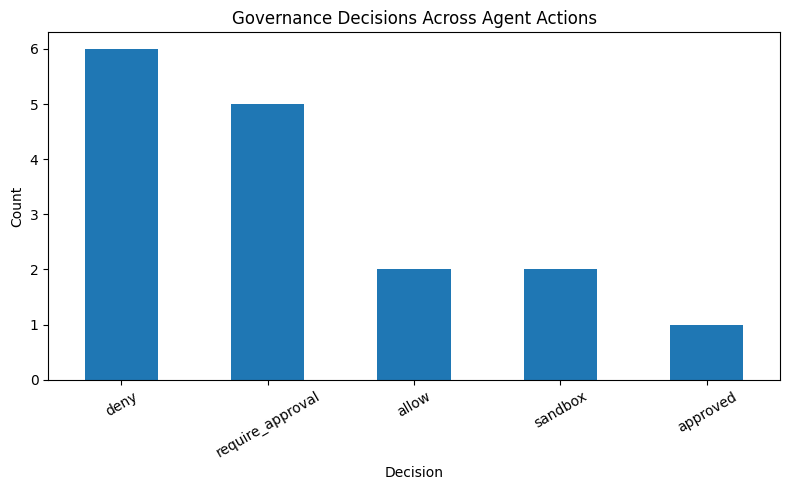

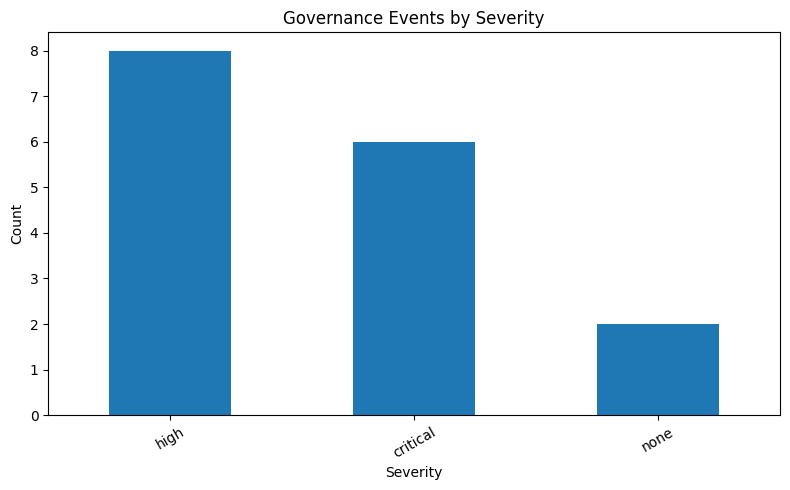

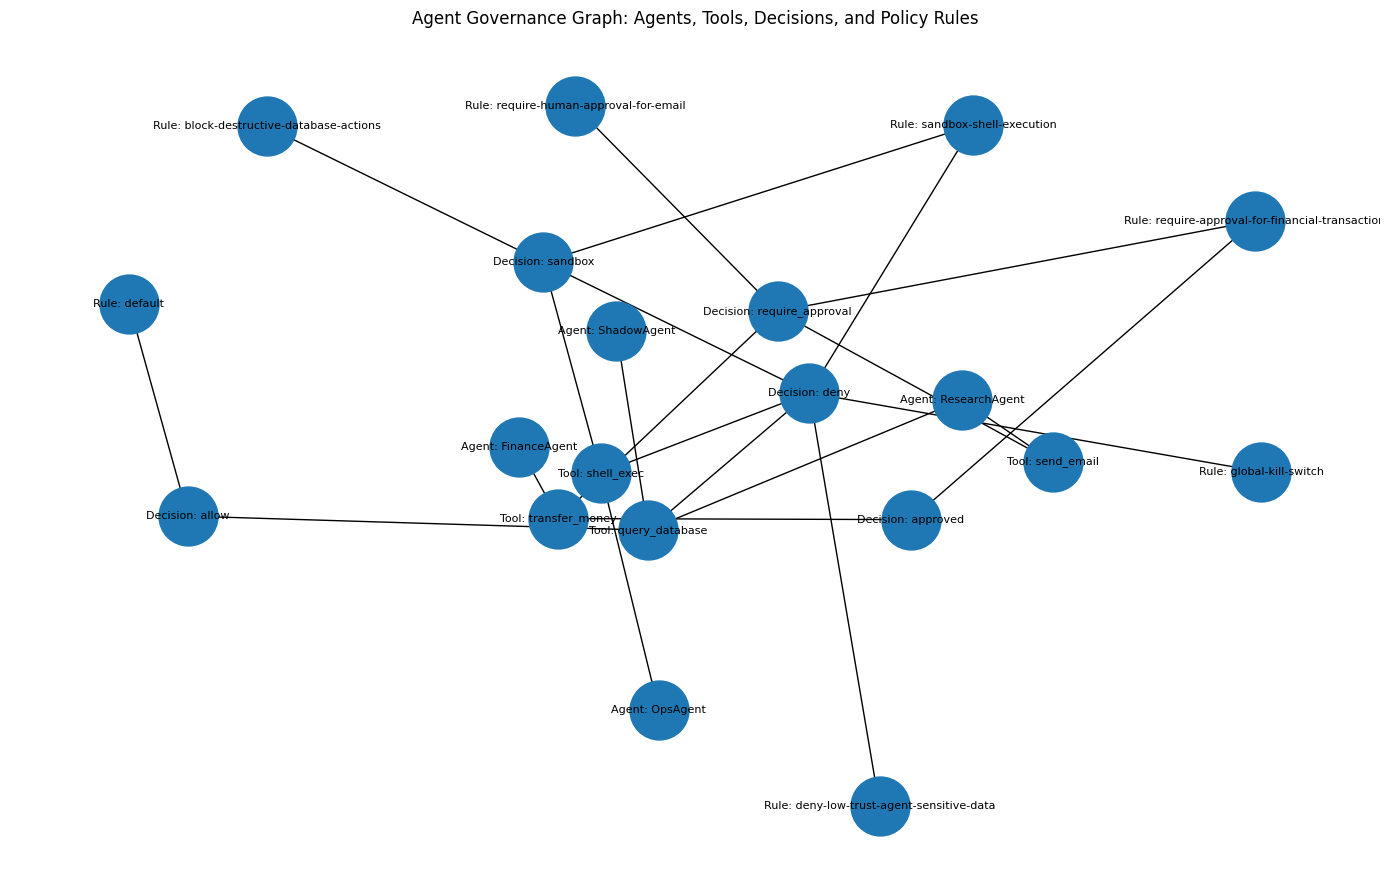

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Tutorial complete.                                                                                              │
│                                                                                                                 │
│ Audit JSON: /content/agt_tutorial_outputs/tamper_evident_audit_log.json                                         │
│ Audit CSV: /content/agt_tutorial_outputs/governance_audit_log.csv                                               │
│ Policy YAML: /content/agt_tutorial_outputs/advanced_agent_policy.yaml                                           │
│ Policy tests: /content/agt_tutorial_outputs/policy_test_results.csv                                             │
│                                                                                                                 │
│ You now have a complete governed-agent runtime pattern with policy checks, identity, approval gates, sandbox    │
│ decisions, audit logs, SRE kill switch, analytics, and graph visualization.                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────── Mapping to Official Toolkit Pattern ──────────────────────╮
│                                                                                │
│ Official AGT-style usage is conceptually:                                      │
│                                                                                │
│ from agentmesh.governance import govern                                        │
│                                                                                │
│ safe_tool = govern(my_tool, policy="policy.yaml")                              │
│ safe_tool(...)                                                                 │
│                                                                                │
│ In this tutorial, GovernedTool plays the same educational role while remaining │
│ stable inside Colab even if public-preview package APIs change.                │
│                                                                                │
╰────────────────────────────────────────────────────────────────────────────────╯

In [1]:
scenarios = [
    {
        "name": "Safe database read",
        "tool": research_db,
        "kwargs": {
            "table": "customers",
            "operation": "select",
            "type": "select",
            "sensitivity": "medium"
        }
    },
    {
        "name": "Blocked destructive database action",
        "tool": research_db,
        "kwargs": {
            "table": "customers",
            "operation": "drop",
            "type": "drop_table",
            "sensitivity": "critical"
        }
    },
    {
        "name": "External email requiring approval",
        "tool": research_email,
        "kwargs": {
            "to": "partner@example.com",
            "recipient_domain": "example.com",
            "subject": "Quarterly update",
            "body": "Sharing a non-confidential quarterly update.",
            "type": "send_email",
            "sensitivity": "medium"
        }
    },
    {
        "name": "External email denied due to approval rejection",
        "tool": research_email,
        "kwargs": {
            "to": "external@example.com",
            "recipient_domain": "example.com",
            "subject": "Confidential strategy",
            "body": "This contains confidential strategy.",
            "type": "send_email",
            "sensitivity": "critical"
        }
    },
    {
        "name": "Safe sandbox shell command",
        "tool": ops_shell,
        "kwargs": {
            "command": "echo Agent governance is active",
            "type": "shell_exec",
            "sensitivity": "low"
        }
    },
    {
        "name": "Dangerous shell command blocked",
        "tool": ops_shell,
        "kwargs": {
            "command": "rm -rf /content/something",
            "type": "shell_exec",
            "sensitivity": "critical"
        }
    },
    {
        "name": "Low-trust agent blocked from sensitive data",
        "tool": shadow_db,
        "kwargs": {
            "table": "executive_compensation",
            "operation": "select",
            "type": "select",
            "sensitivity": "critical"
        }
    },
    {
        "name": "Financial transfer requiring approval",
        "tool": finance_transfer,
        "kwargs": {
            "amount": 2500,
            "destination": "vendor-123",
            "type": "transfer_money",
            "sensitivity": "high"
        }
    },
    {
        "name": "Large financial transfer rejected",
        "tool": finance_transfer,
        "kwargs": {
            "amount": 15000,
            "destination": "vendor-999",
            "type": "transfer_money",
            "sensitivity": "critical"
        }
    },
]

results = []

for scenario in scenarios:
    try:
        output = scenario["tool"](**scenario["kwargs"])
        results.append({
            "scenario": scenario["name"],
            "status": "executed",
            "output": output
        })
    except Exception as e:
        results.append({
            "scenario": scenario["name"],
            "status": "blocked_or_pending",
            "error": str(e)
        })

audit_df = audit_log.to_dataframe()

display_cols = [
    "timestamp",
    "agent_name",
    "tool_name",
    "decision",
    "matched_rule",
    "severity",
    "reason",
    "record_hash"
]

display(audit_df[display_cols])

test_cases = [
    {
        "name": "drop_table must be denied",
        "identity": research_agent,
        "tool_name": "query_database",
        "action": {"type": "drop_table", "sensitivity": "critical", "autonomous": True},
        "expected": "deny"
    },
    {
        "name": "safe select should be allowed",
        "identity": research_agent,
        "tool_name": "query_database",
        "action": {"type": "select", "sensitivity": "low", "autonomous": True},
        "expected": "allow"
    },
    {
        "name": "external email should require approval",
        "identity": research_agent,
        "tool_name": "send_email",
        "action": {
            "type": "send_email",
            "recipient_domain": "example.com",
            "sensitivity": "medium",
            "autonomous": True
        },
        "expected": "require_approval"
    },
    {
        "name": "low trust sensitive access denied",
        "identity": unknown_agent,
        "tool_name": "query_database",
        "action": {"type": "select", "sensitivity": "critical", "autonomous": True},
        "expected": "deny"
    },
    {
        "name": "shell command should enter sandbox",
        "identity": ops_agent,
        "tool_name": "shell_exec",
        "action": {
            "type": "shell_exec",
            "command": "echo hello",
            "sensitivity": "low",
            "autonomous": True
        },
        "expected": "sandbox"
    },
]

test_results = []

for test in test_cases:
    decision = engine.evaluate(
        identity=test["identity"],
        tool_name=test["tool_name"],
        action=test["action"]
    )

    passed = decision.decision == test["expected"]

    test_results.append({
        "test": test["name"],
        "expected": test["expected"],
        "actual": decision.decision,
        "passed": passed,
        "matched_rule": decision.matched_rule
    })

test_df = pd.DataFrame(test_results)
display(test_df)

engine.activate_kill_switch()

try:
    research_db(
        table="customers",
        operation="select",
        type="select",
        sensitivity="low"
    )
except Exception as e:
    pass

engine.deactivate_kill_switch()

audit_df = audit_log.to_dataframe()

summary = (
    audit_df
    .groupby(["decision", "severity"], dropna=False)
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(summary)

agent_summary = (
    audit_df
    .groupby(["agent_name", "decision"])
    .size()
    .reset_index(name="count")
    .sort_values(["agent_name", "count"], ascending=[True, False])
)

display(agent_summary)

decision_counts = audit_df["decision"].value_counts()

plt.figure(figsize=(8, 5))
decision_counts.plot(kind="bar")
plt.title("Governance Decisions Across Agent Actions")
plt.xlabel("Decision")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

severity_counts = audit_df["severity"].fillna("none").value_counts()

plt.figure(figsize=(8, 5))
severity_counts.plot(kind="bar")
plt.title("Governance Events by Severity")
plt.xlabel("Severity")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

G = nx.DiGraph()

for _, row in audit_df.iterrows():
    agent_node = f"Agent: {row['agent_name']}"
    tool_node = f"Tool: {row['tool_name']}"
    decision_node = f"Decision: {row['decision']}"
    rule_node = f"Rule: {row['matched_rule']}" if pd.notna(row["matched_rule"]) else "Rule: default"

    G.add_node(agent_node, node_type="agent")
    G.add_node(tool_node, node_type="tool")
    G.add_node(decision_node, node_type="decision")
    G.add_node(rule_node, node_type="rule")

    G.add_edge(agent_node, tool_node, relation="calls")
    G.add_edge(tool_node, decision_node, relation="produces")
    G.add_edge(decision_node, rule_node, relation="matched")

plt.figure(figsize=(14, 9))
pos = nx.spring_layout(G, seed=42, k=0.8)
nx.draw_networkx_nodes(G, pos, node_size=1800)
nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle="->", arrowsize=15)
nx.draw_networkx_labels(G, pos, font_size=8)
plt.title("Agent Governance Graph: Agents, Tools, Decisions, and Policy Rules")
plt.axis("off")
plt.tight_layout()
plt.show()

EXPORT_DIR = "/content/agt_tutorial_outputs"
os.makedirs(EXPORT_DIR, exist_ok=True)

audit_json_path = os.path.join(EXPORT_DIR, "tamper_evident_audit_log.json")
audit_csv_path = os.path.join(EXPORT_DIR, "governance_audit_log.csv")
policy_copy_path = os.path.join(EXPORT_DIR, "advanced_agent_policy.yaml")
test_results_path = os.path.join(EXPORT_DIR, "policy_test_results.csv")

with open(audit_json_path, "w") as f:
    json.dump([asdict(r) for r in audit_log.records], f, indent=2, default=str)

audit_df.to_csv(audit_csv_path, index=False)
test_df.to_csv(test_results_path, index=False)
shutil.copy(POLICY_PATH, policy_copy_path)